#  F1 Pit Stop Prediction


### Table of contents
1. Load Data
2. Exploratory Data Analysis (EDA)
3. Preprocessing
4. Feature Engineering 
5. Model Training & Evaluation 
6. Ensemble Blending
7. Final Submission

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

## 2. Load Data

In [2]:
df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')

test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')

## 3. Exploratory Data Analysis (EDA)

In [3]:

df.shape
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [5]:
df.isnull().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

In [6]:
df['PitNextLap'].value_counts(normalize=True)

PitNextLap
0.0    0.801018
1.0    0.198982
Name: proportion, dtype: float64

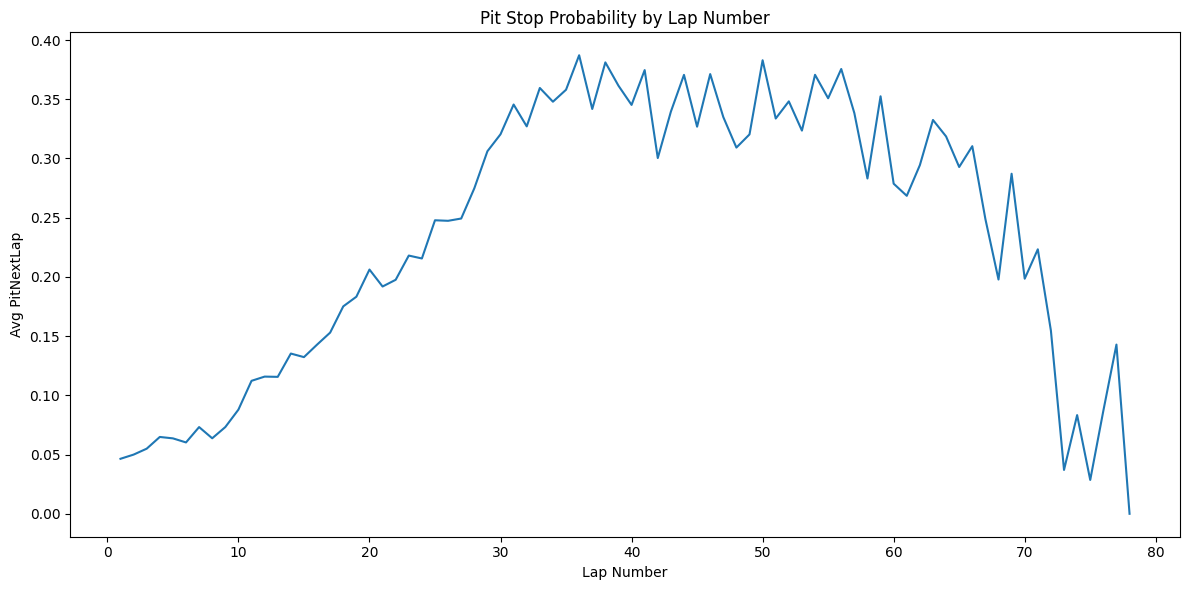

In [7]:
# Shows at which laps pit stops are most likely to happen
df.groupby('LapNumber')['PitNextLap'].mean().plot(figsize=(12, 6),
                                                    title='Pit Stop Probability by Lap Number',
                                                    ylabel='Avg PitNextLap',
                                                    xlabel='Lap Number')
plt.tight_layout()
plt.show()

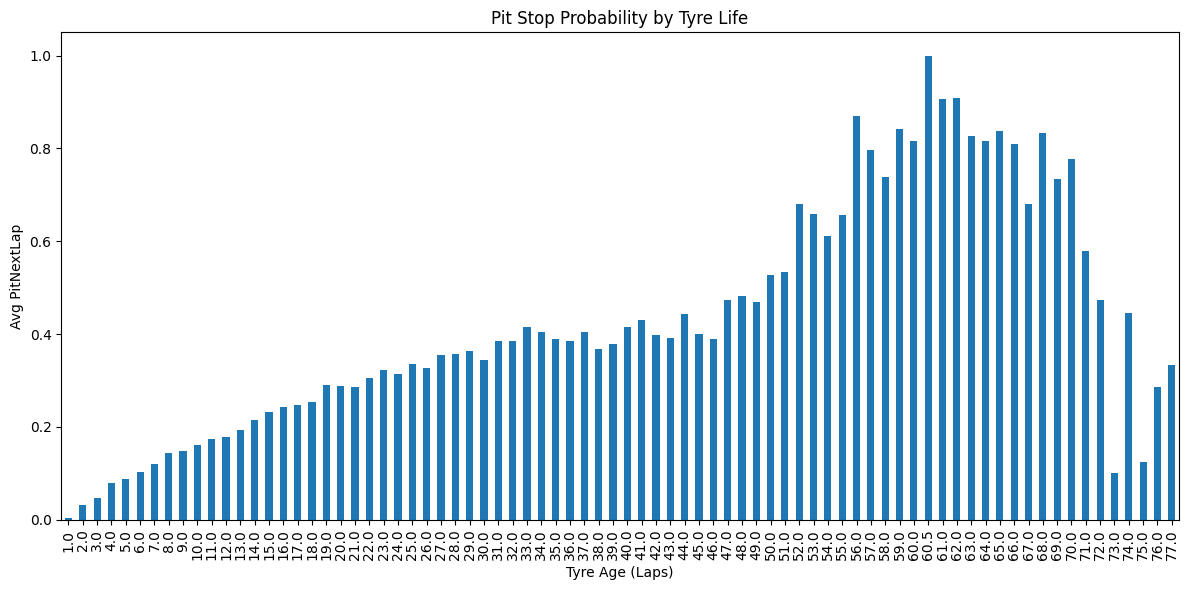

In [8]:
# Older tyres should have a higher pit probability
df.groupby('TyreLife')['PitNextLap'].mean().plot(kind='bar', figsize=(12, 6),
                                                   title='Pit Stop Probability by Tyre Life',
                                                   ylabel='Avg PitNextLap',
                                                   xlabel='Tyre Age (Laps)')
plt.tight_layout()
plt.show()

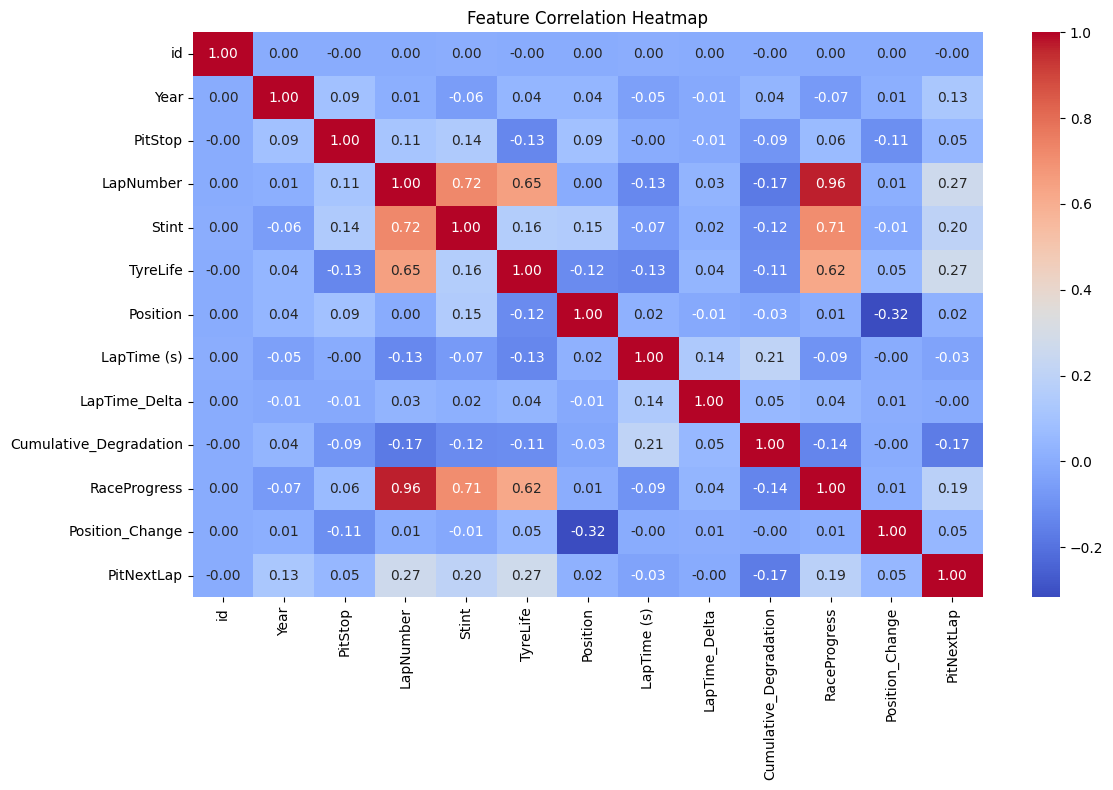

In [9]:
# Helps identify which features are most correlated with the target
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Preprocessing

- Drop columns id, Driver, Race, RaceProgress.

In [10]:
cols_to_drop = ['id', 'Driver', 'Race', 'RaceProgress']
df = df.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)

In [11]:
df = pd.get_dummies(df, columns=['Compound'], dtype=int)
test = pd.get_dummies(test, columns=['Compound'], dtype=int)

df.head()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,Position_Change,PitNextLap,Compound_HARD,Compound_INTERMEDIATE,Compound_MEDIUM,Compound_SOFT,Compound_WET
0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,5.0,1.0,1,0,0,0,0
1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,-3.0,0.0,1,0,0,0,0
2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,3.0,1.0,1,0,0,0,0
3,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.0,0.0,0,0,1,0,0
4,2022,1,26,3,6.0,2,107.878,8.965,-14.139,3.0,0.0,1,0,0,0,0


## 5. Feature Engineering

Adding features to help the model better predict pit stops

In [12]:
def add_features(data):

    # Squared tyre age to capture non-linear degradation
    data['TyreLife_squared'] = data['TyreLife'] ** 2

    # Flag tyres older than 40 laps — high pit risk zone
    data['OldTyre'] = (data['TyreLife'] > 40).astype(int)

    data['LapTime_rolling'] = (
        data.groupby('Stint')['LapTime (s)']
            .transform(lambda x: x.rolling(3, min_periods=1).mean())
    )

    data['LapTime_vs_avg'] = data['LapTime (s)'] - data['LapTime_rolling']

    return data


# Apply to both train and test (same feature names)
df = add_features(df)
test = add_features(test)

print("New features added. Training shape:", df.shape)

New features added. Training shape: (439140, 20)


## 6. Model Training & Evaluation

In [13]:

X = df.drop(columns=['PitNextLap'])
y = df['PitNextLap']


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]} | {X_val.shape[0]}")
print("Features:", X_train.columns.tolist())

Train size: 351312 | 87828
Features: ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'Position_Change', 'Compound_HARD', 'Compound_INTERMEDIATE', 'Compound_MEDIUM', 'Compound_SOFT', 'Compound_WET', 'TyreLife_squared', 'OldTyre', 'LapTime_rolling', 'LapTime_vs_avg']


### 6.1 XGBoost

In [14]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,  
    max_depth=6,
    subsample=0.8,          
    colsample_bytree=0.8,    
    random_state=42,
    eval_metric='auc'
)

xgb_model.fit(X_train, y_train)


val_preds_xgb = xgb_model.predict_proba(X_val)[:, 1]
auc_xgb = roc_auc_score(y_val, val_preds_xgb)
print(f"XGBoost Validation AUC: {auc_xgb:.4f}")

XGBoost Validation AUC: 0.9437


### 6.2 LightGBM

In [15]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model.fit(X_train, y_train)


val_preds_lgbm = lgbm_model.predict_proba(X_val)[:, 1]
auc_lgbm = roc_auc_score(y_val, val_preds_lgbm)
print(f"LightGBM Validation AUC: {auc_lgbm:.4f}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69839, number of negative: 281473
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.036234 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1593
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198795 -> initscore=-1.393844
[LightGBM] [Info] Start training from score -1.393844
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM Validation AUC: 0.9424


### 6.3 CatBoost

In [16]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0           
)

cat_model.fit(X_train, y_train)


val_preds_cat = cat_model.predict_proba(X_val)[:, 1]
auc_cat = roc_auc_score(y_val, val_preds_cat)
print(f"CatBoost Validation AUC: {auc_cat:.4f}")

CatBoost Validation AUC: 0.9388


### 6.4 Ensemble: Average Blending

Averaging predictions from XGBoost and LightGBM — diverse models that often complement each other's weaknesses.

In [17]:
# Simple average of XGBoost and LightGBM probabilities
blended_preds = (val_preds_xgb + val_preds_lgbm) / 2
auc_blend = roc_auc_score(y_val, blended_preds)
print(f"Blended (XGB + LGBM) Validation AUC: {auc_blend:.4f}")

Blended (XGB + LGBM) Validation AUC: 0.9433


### 6.5 XGBoost with Early Stopping (Best Model)

Using a much higher `n_estimators` with early stopping — training stops automatically when validation AUC stops improving, preventing overfitting.

In [18]:

xgb_final = XGBClassifier(
    n_estimators=5000,           
    learning_rate=0.02,          
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50     
)

xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],  
    verbose=500                  
)

val_preds_final = xgb_final.predict_proba(X_val)[:, 1]
auc_final = roc_auc_score(y_val, val_preds_final)
print(f"\nFinal XGBoost (Early Stopping) Validation AUC: {auc_final:.4f}")

[0]	validation_0-auc:0.89112
[500]	validation_0-auc:0.94035
[1000]	validation_0-auc:0.94318
[1500]	validation_0-auc:0.94431
[2000]	validation_0-auc:0.94482
[2500]	validation_0-auc:0.94509
[2854]	validation_0-auc:0.94518

Final XGBoost (Early Stopping) Validation AUC: 0.9452


### 6.6 Results Summary

In [19]:
# model results side by side for easy comparison
results = {
    'XGBoost (500 trees)':             auc_xgb,
    'LightGBM (500 trees)':            auc_lgbm,
    'CatBoost (500 iterations)':       auc_cat,
    'Blend (XGB + LGBM)':              auc_blend,
    'XGBoost (Early Stopping)':        auc_final,
}

print("Model Comparison (Validation AUC)")
print("-" * 45)
for model_name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:<35} {score:.4f}")

Model Comparison (Validation AUC)
---------------------------------------------
XGBoost (Early Stopping)            0.9452
XGBoost (500 trees)                 0.9437
Blend (XGB + LGBM)                  0.9433
LightGBM (500 trees)                0.9424
CatBoost (500 iterations)           0.9388


## 7. Generate Submission

Using the best model (XGBoost with Early Stopping) for the final submission.

In [20]:

test_preds = xgb_final.predict_proba(test)[:, 1]


submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv')
submission['PitNextLap'] = test_preds


submission.to_csv('submission.csv', index=False)
print("Submission saved to submission.csv")
print(submission.head())

Submission saved to submission.csv
       id  PitNextLap
0  439140    0.003926
1  439141    0.001899
2  439142    0.002226
3  439143    0.150972
4  439144    0.778110
